### Imports

In [69]:
import numpy as np
import matplotlib.pyplot as plt
from spectral import *
import seaborn as sns

### 1. Loading the image

In [70]:
hyperimg = np.load(r"/Users/simenkrogstie/Documents/Programming/Høst 2024/INF250/Mandatory Exercise 3/sandvika.npy")

### 2. Function to fetch band numbers 

In [71]:
# Read wavelenghts from header
wavelengths = envi.read_envi_header('Visnir.hdr')['wavelength']
wavelengths = [float(i) for i in wavelengths]     # Ensure elements are floats. 

In [72]:
def fetch_band_num(list):
    target_wavelengths = {
        "blue" : 440,
        "green" : 535,
        "red" : 645,
        "NIR" : 800
    }
    
    w_array = np.array(list)    

    band_num = {}
    for key, value in target_wavelengths.items():
        band_number = int(np.argmin(np.abs(w_array - value)))
        band_num[key] = band_number
    
    return band_num

band_numbers = fetch_band_num(wavelengths)

### 3. Displaying an RGB image from the hyperspectral image

ImageView object:
  Display bands       :  (75, 40, 10)
  Interpolation       :  <default>
  RGB data limits     :
    R: [46.91428756713867, 1503.4857177734375]
    G: [62.228572845458984, 1130.971435546875]
    B: [18.02857208251953, 945.0]

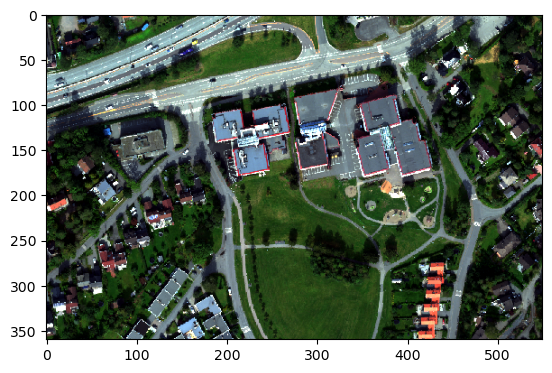

In [73]:
red_band = band_numbers['red']
nir_band = band_numbers['NIR']
green_band = band_numbers['green']
blue_band = band_numbers['blue']

imshow(hyperimg, (red_band, green_band, blue_band), stretch=((0.02,0.98),(0.02,0.98),(0.02,0.98)))

### 4. Function that computes the NDVI Index

In [74]:
def ndvi_index(red, nir):
    ndvi = (nir-red)/(nir+red + 1e-10) # Adding small constant to ensure no division on zero.
    return ndvi

### 5. Display the NDVI image

In [75]:
red = hyperimg[:,:,red_band]
nir = hyperimg[:,:,nir_band]
green = hyperimg[:,:,green_band]
blue = hyperimg[:,:,blue_band]

(-0.5, 549.5, 359.5, -0.5)

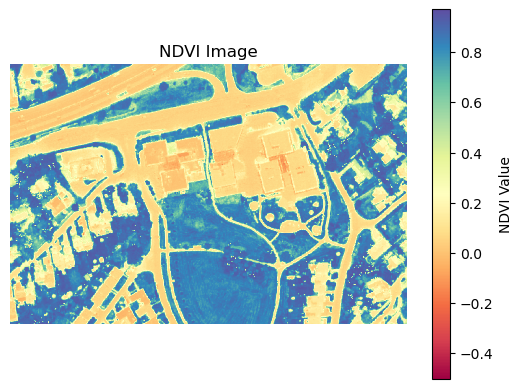

In [76]:
ndvi_image = ndvi_index(red, nir)
plt.imshow(ndvi_image, cmap='Spectral')
plt.title('NDVI Image')
plt.colorbar(label='NDVI Value')
plt.axis('off')

### 6. Plot spectra of a point with vegetation, asphalt and roof

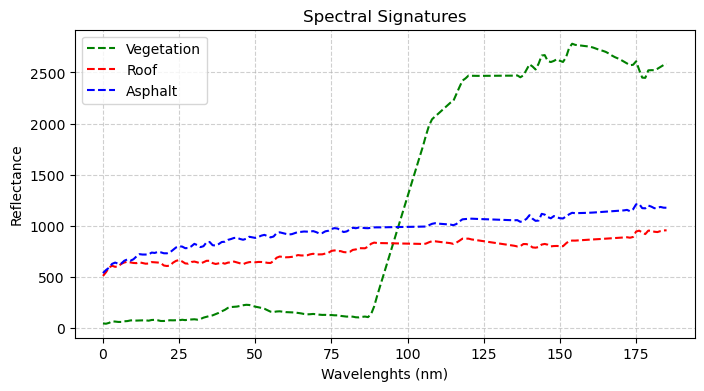

In [77]:
vegetation = np.array(hyperimg[280,330,:].reshape(-1, 1))
roof = np.array(hyperimg[150,210,:].reshape(-1, 1))
asphalt =  np.array(hyperimg[90,170,:].reshape(-1, 1))

plt.figure(figsize=(8, 4))
plt.plot(vegetation, label='Vegetation', linestyle='dashed', color='green')
plt.plot(roof, label='Roof', linestyle='dashed', color='red')
plt.plot(asphalt, label='Asphalt', linestyle='dashed', color='blue')
plt.xlabel('Wavelenghts (nm)')
plt.ylabel('Reflectance')
plt.title('Spectral Signatures')
plt.legend(loc='upper left')
plt.grid(True, linestyle='--', alpha=0.6)

### 7. Histogram of NDVI values

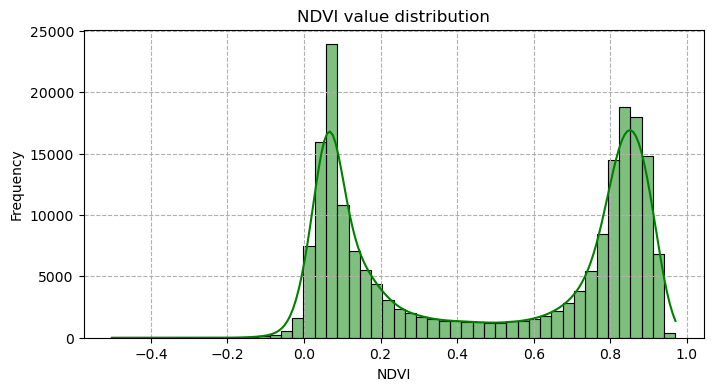

In [78]:
ndvi_flattened = ndvi_image.flatten()

plt.figure(figsize=(8, 4))
sns.histplot(ndvi_flattened, bins=50, kde=True, color='green')
plt.title('NDVI value distribution')
plt.xlabel('NDVI')
plt.ylabel('Frequency')
plt.grid(True, linestyle='--')
plt.show()

### 8. Making a NDVI threshold (NDVI > 0.6 is set to zero)

(-0.5, 549.5, 359.5, -0.5)

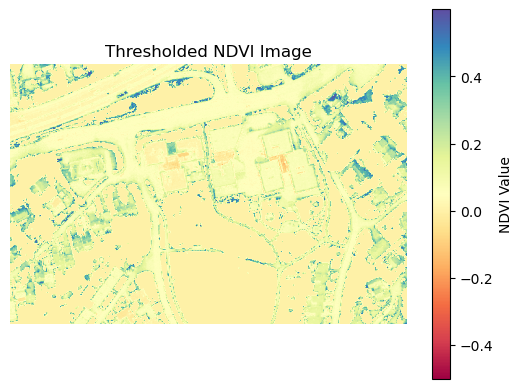

In [79]:
modified_ndvi = np.copy(ndvi_image)
modified_ndvi[modified_ndvi > 0.6] = 0 # np.nan()

plt.imshow(modified_ndvi, cmap='Spectral')
plt.title('Thresholded NDVI Image')
plt.colorbar(label='NDVI Value')
plt.axis('off')

### 10. PCA

In [80]:
pc = principal_components(hyperimg)
pc_0999 = pc.reduce(fraction=0.999)

# Scores
img_pc = pc_0999.transform(hyperimg)

# Loadings
loadings = pc_0999.eigenvectors

/var/folders/sj/p7jz762n09j7jz2k9h7bd_y80000gn/T/ipykernel_47041/2831260242.py:1: DeprecationWarning: `alltrue` is deprecated as of NumPy 1.25.0, and will be removed in NumPy 2.0. Please use `all` instead.
  pc = principal_components(hyperimg)


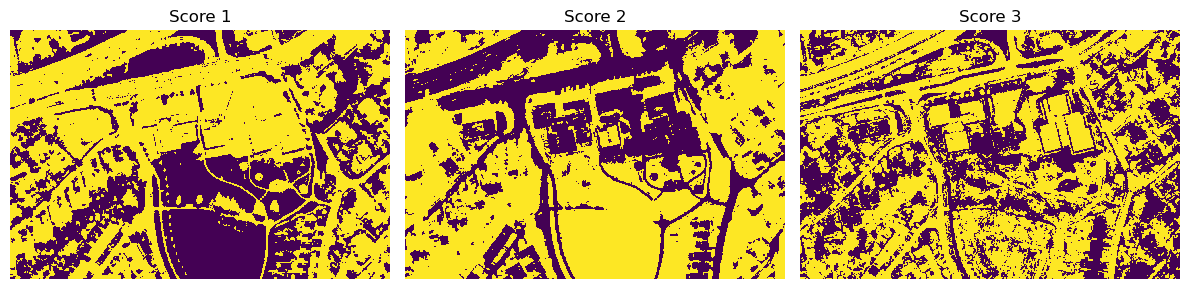

In [81]:
# Scores plot
fig, ax = plt.subplots(1, 3, figsize=(12, 4))

ax[0].imshow(img_pc[:,:,0], vmin=0.1, vmax=0.15)
ax[0].set_title('Score 1')
ax[0].axis('off')

ax[1].imshow(img_pc[:,:,1], vmin=0.1, vmax=0.15)
ax[1].set_title('Score 2')
ax[1].axis('off')

ax[2].imshow(img_pc[:,:,2], vmin=0.1, vmax=0.15)
ax[2].set_title('Score 3')
ax[2].axis('off')

plt.tight_layout()
plt.show()

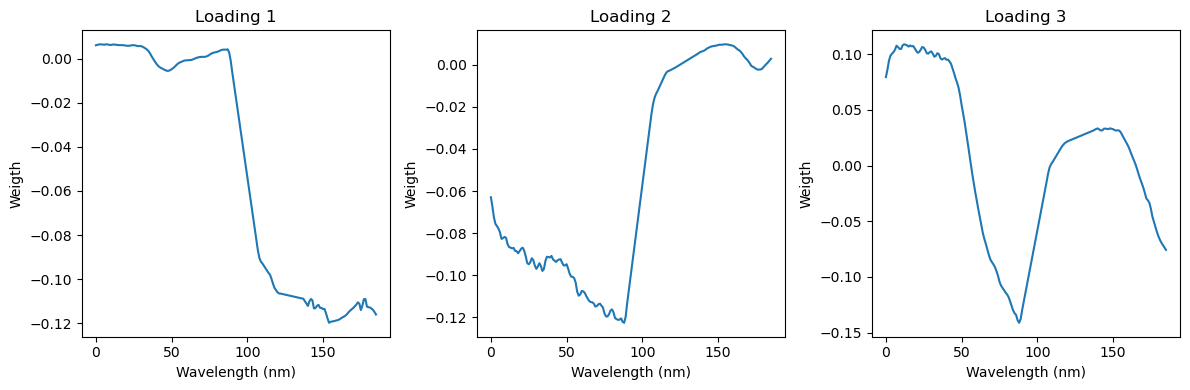

In [82]:
# Loadings plot

fig, ax = plt.subplots(1, 3, figsize=(12, 4))
ax[0].plot(loadings[:,[0]])
ax[0].set_title('Loading 1')
ax[0].set_xlabel('Wavelength (nm)')
ax[0].set_ylabel('Weigth')

ax[1].plot(loadings[:,[1]])
ax[1].set_title('Loading 2')
ax[1].set_xlabel('Wavelength (nm)')
ax[1].set_ylabel('Weigth')

ax[2].plot(loadings[:,[2]])
ax[2].set_title('Loading 3')
ax[2].set_xlabel('Wavelength (nm)')
ax[2].set_ylabel('Weigth')

plt.tight_layout()
plt.show()

### 11. K-means clustering

In [83]:
(m,c) = kmeans(img_pc, 3, 10)

spectral:INFO: k-means iteration 1 - 197998 pixels reassigned.


spectral:INFO: k-means iteration 2 - 849 pixels reassigned.
spectral:INFO: k-means iteration 3 - 1432 pixels reassigned.
spectral:INFO: k-means iteration 4 - 10577 pixels reassigned.
spectral:INFO: k-means iteration 5 - 41569 pixels reassigned.
spectral:INFO: k-means iteration 6 - 14317 pixels reassigned.
spectral:INFO: k-means iteration 7 - 4495 pixels reassigned.
spectral:INFO: k-means iteration 8 - 1495 pixels reassigned.
spectral:INFO: k-means iteration 9 - 471 pixels reassigned.
spectral:INFO: k-means iteration 10 - 153 pixels reassigned.
spectral:INFO: kmeans terminated with 3 clusters after 10 iterations.


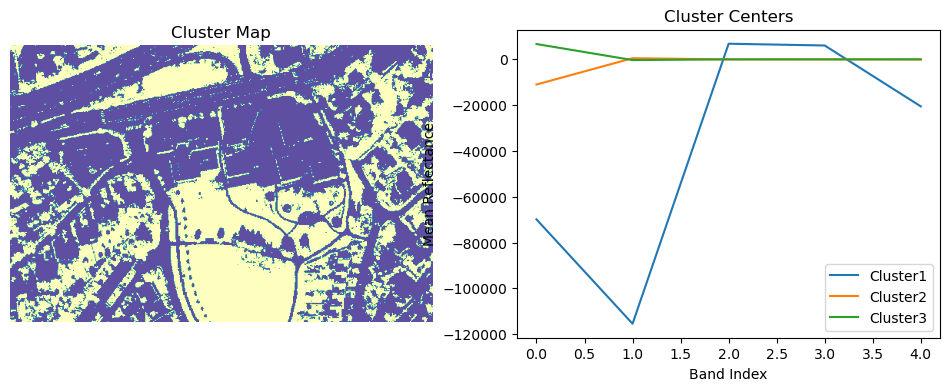

In [84]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

ax[0].imshow(m, 'Spectral')
ax[0].set_title('Cluster Map')
ax[0].axis('off')

for i in range(c.shape[0]):
    ax[1].plot(c[i], label=f'Cluster{i+1}')
ax[1].set_title('Cluster Centers')
ax[1].set_xlabel('Band Index')
ax[1].set_ylabel('Mean Reflectance')
ax[1].legend()